___

<a href='http://www.pieriandata.com'><img src='../Pierian_Data_Logo.png'/></a>
___
<center><em>Copyright Pierian Data</em></center>
<center><em>For more information, visit us at <a href='http://www.pieriandata.com'>www.pieriandata.com</a></em></center>

# Pandas Time Series Exercise Set #1

For this set of exercises we'll use a dataset containing monthly milk production values in pounds per cow from January 1962 to December 1975.

<div class="alert alert-danger" style="margin: 10px"><strong>IMPORTANT NOTE!</strong> Make sure you don't run the cells directly above the example output shown, <br>otherwise you will end up writing over the example output!</div>

In [10]:
pwd

'c:\\Users\\ahmad\\Desktop\\Investing\\Jose-Portilla-Python for Time Series Analysis\\UDEMY_TSA_FINAL\\UDEMY_TSA_FINAL\\04-Time-Series-with-Pandas'

In [ ]:
# RUN THIS CELL
import pandas as pd
import matplotlib.pyplot as plt 
plt.style.use("fivethirtyeight")
%matplotlib inline
import numpy as np

df = pd.read_csv('../Data/monthly_milk_production.csv', encoding='utf8')
title = "Monthly milk production: pounds per cow. Jan '62 - Dec '75"

print(len(df))
print(df.head())

168
      Date  Production
0  1962-01         589
1  1962-02         561
2  1962-03         640
3  1962-04         656
4  1962-05         727


So <tt>df</tt> has 168 records and 2 columns.

### 1. What is the current data type of the Date column?
HINT: We show how to list column dtypes in the first set of DataFrame lectures.

In [19]:
# CODE HERE
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


### 2. Change the Date column to a datetime format

In [24]:
df.Date

0      1962-01
1      1962-02
2      1962-03
3      1962-04
4      1962-05
        ...   
163    1975-08
164    1975-09
165    1975-10
166    1975-11
167    1975-12
Name: Date, Length: 168, dtype: object

In [26]:
df.Date = pd.to_datetime(df.Date , format = "%Y-%m")
df.Date

0     1962-01-01
1     1962-02-01
2     1962-03-01
3     1962-04-01
4     1962-05-01
         ...    
163   1975-08-01
164   1975-09-01
165   1975-10-01
166   1975-11-01
167   1975-12-01
Name: Date, Length: 168, dtype: datetime64[ns]

In [27]:
df.Date.info()

<class 'pandas.core.series.Series'>
RangeIndex: 168 entries, 0 to 167
Series name: Date
Non-Null Count  Dtype         
--------------  -----         
168 non-null    datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 1.4 KB


### 3. Set the Date column to be the new index

In [28]:
df.set_index('Date', inplace=True)
df.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


### 4. Plot the DataFrame with a simple line plot. What do you notice about the plot?

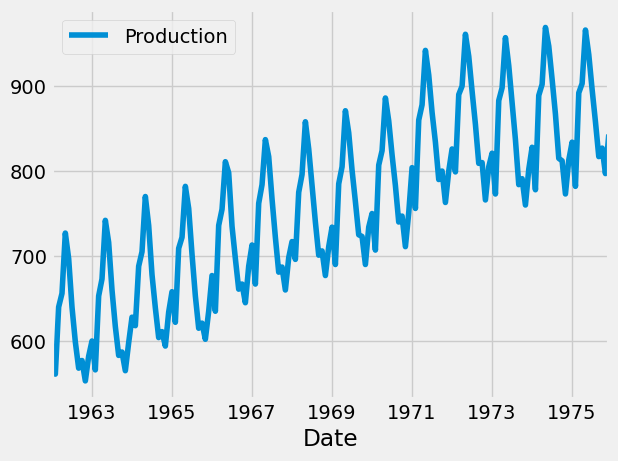

In [32]:
df.plot();

### 5. Add a column called 'Month' that takes the month value from the index
HINT: You have to call <tt>df.index</tt> as <tt>df['Date']</tt> won't work.

<strong>BONUS: See if you can obtain the <em>name</em> of the month instead of a number!</strong>

In [34]:
df.index.month_name()

Index(['January', 'February', 'March', 'April', 'May', 'June', 'July',
       'August', 'September', 'October',
       ...
       'March', 'April', 'May', 'June', 'July', 'August', 'September',
       'October', 'November', 'December'],
      dtype='object', name='Date', length=168)

In [ ]:
df["Month"] = df.index.month

In [36]:
df

,Production,Month
Date,,
1962-01-01,589,1
1962-02-01,561,2
1962-03-01,640,3
1962-04-01,656,4
1962-05-01,727,5
...,...,...
1975-08-01,858,8
1975-09-01,817,9
1975-10-01,827,10


In [69]:
df["Month_Name"] = df.index.month_name()
df

,Production,Month,Month_Name
Date,,,
1962-01-01,589,1,January
1962-02-01,561,2,February
1962-03-01,640,3,March
1962-04-01,656,4,April
1962-05-01,727,5,May
...,...,...,...
1975-08-01,858,8,August
1975-09-01,817,9,September
1975-10-01,827,10,October


In [45]:
df.drop(columns=["Month_Name"], inplace=True)

In [52]:
df.head()

,Production,Month
Date,,
1962-01-01,589,1
1962-02-01,561,2
1962-03-01,640,3
1962-04-01,656,4
1962-05-01,727,5


In [53]:
df.tail()

,Production,Month
Date,,
1975-08-01,858,8
1975-09-01,817,9
1975-10-01,827,10
1975-11-01,797,11
1975-12-01,843,12


### 6. Create a BoxPlot that groups by the Month field

In [62]:
df.groupby("Month")["Production"].describe()

,count,mean,std,min,25%,50%,75%,max
Month,,,,,,,,
1,14.0,727.071429,87.409262,589.0,662.75,725.5,816.75,834.0
2,14.0,689.285714,80.875430,561.0,625.25,693.0,768.75,799.0
3,14.0,783.500000,90.143262,640.0,715.75,780.0,877.25,892.0
4,14.0,800.071429,88.392885,656.0,730.25,800.5,893.00,903.0
5,14.0,862.785714,87.209014,727.0,789.25,864.5,953.25,969.0
6,14.0,836.142857,87.103702,697.0,766.50,835.5,921.25,947.0
7,14.0,788.071429,93.930796,640.0,710.25,792.0,878.00,908.0
8,14.0,747.500000,95.318696,599.0,664.00,752.0,836.25,867.0
9,14.0,706.642857,89.869655,568.0,626.50,713.0,788.50,817.0


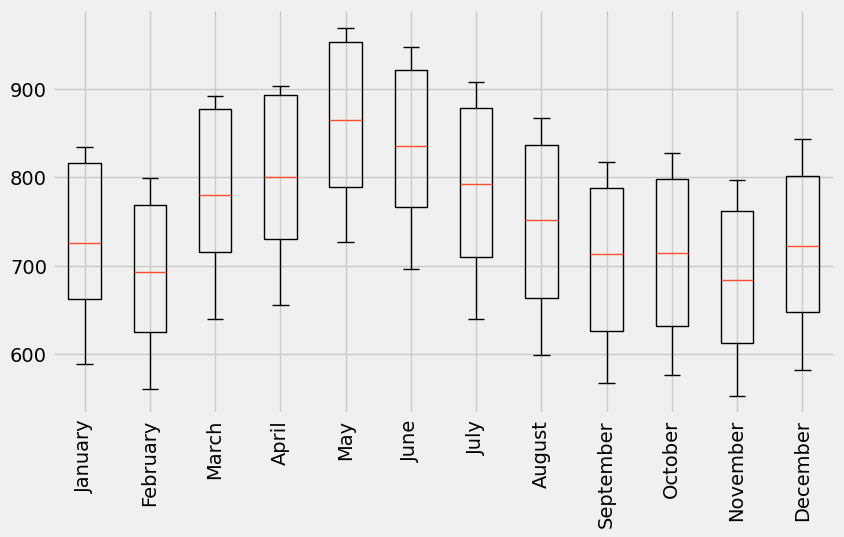

In [74]:
plt.figure(figsize=(9,5))
plt.boxplot(df.groupby("Month")["Production"].apply(list), labels=df["Month_Name"].unique())
plt.xticks(rotation=90)
plt.show()

# Great Job!